# Faz 2 — Çift Yönlü LSTM (BiLSTM) Modeli

Bölüm 5.1.1'de açıklanan BiLSTM mimarisi.  
Rapor hedef metrikleri: **%81.2 doğruluk**

In [1]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import classification_report, accuracy_score
import plotly.graph_objects as go

from data_processing import prepare_balanced_data
from graphic import plot_dual_confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cpu


In [2]:
# Dengeli veri seti yükle
train_df, test_df = prepare_balanced_data("data/real-news.txt", "data/fake-news.txt")
print(f"Eğitim: {len(train_df)} örnek")
print(f"Test:   {len(test_df)} örnek")
print("\nEğitim sınıf dağılımı:")
print(train_df["is_real"].value_counts())

Eğitim: 14635 örnek
Test:   3659 örnek

Eğitim sınıf dağılımı:
is_real
1    7318
0    7317
Name: count, dtype: int64


In [3]:
# Basit kelime düzeyi tokenizer
class Vocabulary:
    PAD, UNK = 0, 1

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}

    def build(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(text.split())
        for word, freq in counter.items():
            if freq >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"Kelime hazinesi boyutu: {len(self.word2idx)}")

    def encode(self, text, max_len=64):
        tokens = text.split()[:max_len]
        ids = [self.word2idx.get(t, self.UNK) for t in tokens]
        ids += [self.PAD] * (max_len - len(ids))
        return ids

vocab = Vocabulary(min_freq=2)
vocab.build(train_df["text"].tolist())

Kelime hazinesi boyutu: 24092


In [4]:
MAX_LEN = 64

class NewsDataset(Dataset):
    def __init__(self, df, vocab, max_len=64):
        self.data = [
            (vocab.encode(row["text"], max_len), int(row["is_real"]))
            for _, row in df.iterrows()
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.float)

BATCH_SIZE = 64
train_dataset = NewsDataset(train_df, vocab, MAX_LEN)
test_dataset  = NewsDataset(test_df,  vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f"Eğitim batch sayısı: {len(train_loader)}")

Eğitim batch sayısı: 229


In [5]:
from bilstm_model import BiLSTMClassifier

model = BiLSTMClassifier(len(vocab.word2idx)).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nToplam parametre: {total_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(24092, 128, padding_idx=0)
  (bilstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Toplam parametre: 3,348,225


In [6]:
# Adam optimizer (Bölüm 5.1.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

EPOCHS = 10
train_accs, val_accs, train_losses = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += ((preds >= 0.5).float() == y_batch).sum().item()
        total += len(y_batch)

    train_acc = correct / total
    train_loss = total_loss / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            val_correct += ((preds >= 0.5).float() == y_batch).sum().item()
            val_total += len(y_batch)
    val_acc = val_correct / val_total

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}")

Epoch 01/10  Loss: 0.6346  Train Acc: 0.6307  Val Acc: 0.6805
Epoch 02/10  Loss: 0.4906  Train Acc: 0.7666  Val Acc: 0.7283
Epoch 03/10  Loss: 0.3516  Train Acc: 0.8515  Val Acc: 0.7486
Epoch 04/10  Loss: 0.2232  Train Acc: 0.9119  Val Acc: 0.7524
Epoch 05/10  Loss: 0.1232  Train Acc: 0.9570  Val Acc: 0.7576
Epoch 06/10  Loss: 0.0747  Train Acc: 0.9757  Val Acc: 0.7477
Epoch 07/10  Loss: 0.0423  Train Acc: 0.9878  Val Acc: 0.7453
Epoch 08/10  Loss: 0.0249  Train Acc: 0.9940  Val Acc: 0.7565
Epoch 09/10  Loss: 0.0128  Train Acc: 0.9971  Val Acc: 0.7513
Epoch 10/10  Loss: 0.0066  Train Acc: 0.9988  Val Acc: 0.7513


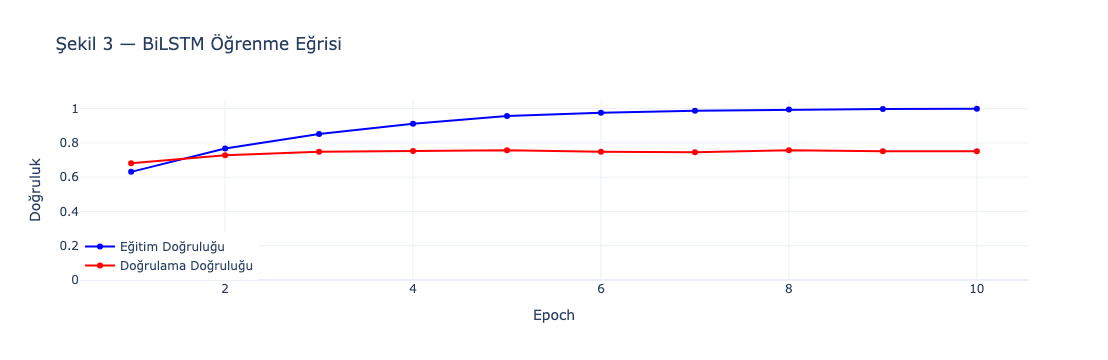

In [7]:
# Şekil 3 — Öğrenme Eğrisi (BiLSTM)
epochs_x = list(range(1, EPOCHS + 1))

fig = go.Figure()
fig.add_trace(go.Scatter(x=epochs_x, y=train_accs, mode="lines+markers",
                          name="Eğitim Doğruluğu", line=dict(color="blue")))
fig.add_trace(go.Scatter(x=epochs_x, y=val_accs, mode="lines+markers",
                          name="Doğrulama Doğruluğu", line=dict(color="red")))
fig.update_layout(
    title="Şekil 3 — BiLSTM Öğrenme Eğrisi",
    xaxis_title="Epoch", yaxis_title="Doğruluk",
    yaxis=dict(range=[0, 1.05]),
    template="plotly_white", legend=dict(x=0, y=0),
)
fig.show()

In [8]:
# Test seti değerlendirmesi
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        probs = model(x_batch).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy().astype(int))

print("BiLSTM Test Sonuçları:")
print(classification_report(all_labels, all_preds, target_names=["Sahte", "Gerçek"]))
print(f"Genel Doğruluk: {accuracy_score(all_labels, all_preds):.4f}")

BiLSTM Test Sonuçları:
              precision    recall  f1-score   support

       Sahte       0.75      0.75      0.75      1830
      Gerçek       0.75      0.76      0.75      1829

    accuracy                           0.75      3659
   macro avg       0.75      0.75      0.75      3659
weighted avg       0.75      0.75      0.75      3659

Genel Doğruluk: 0.7513


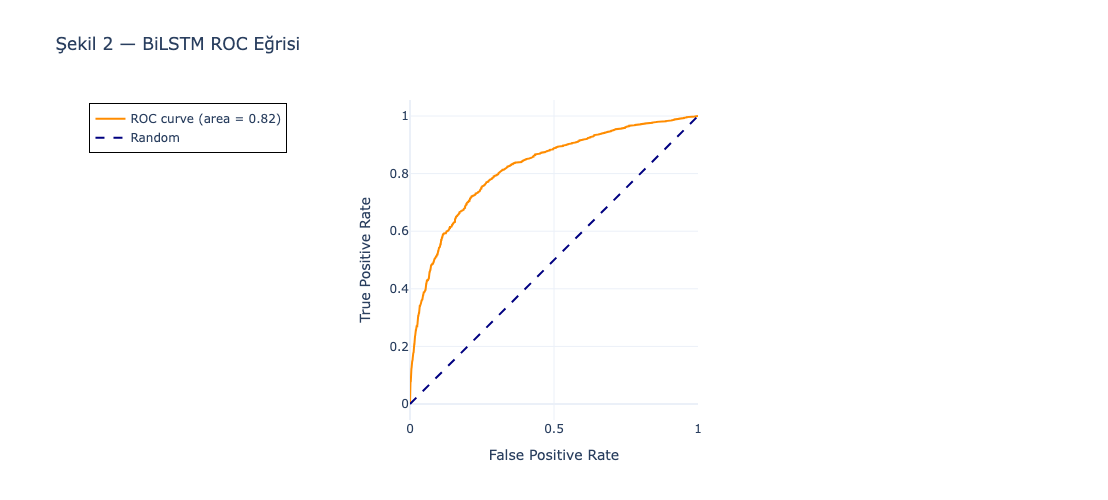

In [9]:
# Şekil 2 — ROC Eğrisi (BiLSTM)
from graphic import plot_roc_curve_plotly
fig_roc = plot_roc_curve_plotly(all_labels, all_probs)
fig_roc.update_layout(title="Şekil 2 — BiLSTM ROC Eğrisi")
fig_roc.show()

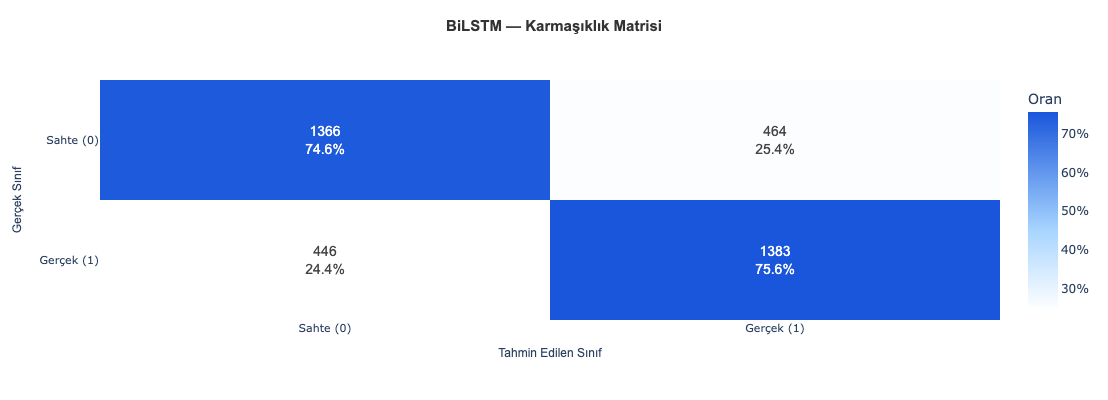

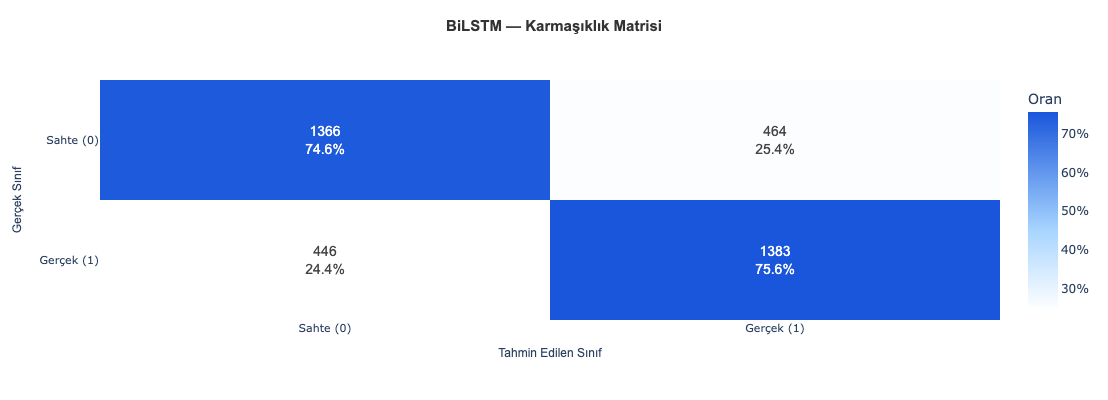

In [10]:
# Confusion Matrix
from graphic import plot_confusion_matrix
plot_confusion_matrix("BiLSTM — Karmaşıklık Matrisi", all_labels, all_preds)

In [11]:
# Modeli kaydet
import os
os.makedirs("models", exist_ok=True)
torch.save({
    "model_state": model.state_dict(),
    "vocab": vocab.word2idx,
    "max_len": MAX_LEN,
}, "models/bilstm_model.pt")
print("BiLSTM modeli models/bilstm_model.pt konumuna kaydedildi.")

BiLSTM modeli models/bilstm_model.pt konumuna kaydedildi.
